In [1]:
import numpy as np
import matplotlib.pyplot as plt
import cartopy
import cartopy.feature as cfeature
import cartopy.crs as ccrs
import xarray as xr
import regionmask
from tqdm import tqdm
from grid import *

Cargamos la máscara de la librería *regionmask*

In [2]:
longitude = np.arange(-180, 180)
latitude = np.arange(-90, 90)

basins = regionmask.defined_regions.natural_earth_v5_0_0.ocean_basins_50
mask = basins.mask(longitude, latitude)

/var/folders/qd/9gm8pvgj6m940047172pfyg80000gn/T/ipykernel_27236/4059174261.py:4: UserWarning: `natural_earth_v5_0_0.ocean_basins_50` does not quite extend to 180°E - it's recommended to use `natural_earth_v5_1_2.ocean_basins_50` instead. See https://github.com/regionmask/regionmask/issues/410.
  basins = regionmask.defined_regions.natural_earth_v5_0_0.ocean_basins_50


En el norte del caribe hay una cuenca separada, que vamos a unir con el atlántico norte. También vamos a separar entre atlántico oeste y este, para norte y sur.

In [3]:
mask_60 = mask.where(mask == 60).values * 0 + 2 
mask_ANE = mask.where(mask == 2).where(mask.lon >= -40).values * 0 + 114
mask_ANW = mask.where(mask == 2).where(mask.lon < -40).values * 0 + 2
mask_ASE = mask.where(mask == 6).where(mask.lon >= -20).values * 0 + 115
mask_ASW = mask.where(mask == 6).where(mask.lon < -20).values * 0 + 6
mask_rest = mask.where(mask != 2).where(mask != 6).where(mask != 60).values
mask_arr = np.concatenate([mask_rest[..., None], mask_60[..., None], mask_ANE[..., None], mask_ANW[..., None], mask_ASE[..., None], mask_ASW[..., None]], axis = -1)
mask_arr = np.nansum(mask_arr, axis = -1)

Insertamos la máscara que creamos en la celda anterior en el dataset de la malla, asegurándonos que tiene las mismas coordenadas (dimensiones) que el resto de variables.

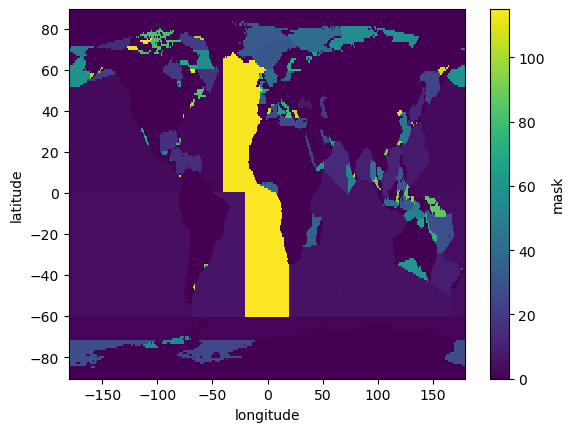

In [4]:
ds = xr.open_dataset("./Data/Grid/grid_1_sal_45k_n1.nc")
ds = ds.where(ds.latitude < 90, drop = True).where(ds.longitude < 180, drop = True)

ds["mask"] = xr.DataArray(mask_arr, coords = dict(
    latitude = (["latitude"], np.arange(-90, 90)),
    longitude = (["longitude"], np.arange(-180, 180))
))
ds.mask.plot()

Como hemos asignado a atlántico noreste y sureste otros flags distintos, creamos una lista que los contenga. Luego, se hace un bucle en esa lista, se enmascara el ds en la cuenca, se hace la media, y se crea un array con nans, y el valor de la media de la tendencia por toda la cuenca. Este array a su vez se mete al diccionario *means_basins*.

In [6]:
ds

<xarray.Dataset> Size: 209MB
Dimensions:    (latitude: 180, longitude: 360, depth: 100)
Coordinates:
  * latitude   (latitude) int64 1kB -90 -89 -88 -87 -86 -85 ... 85 86 87 88 89
  * longitude  (longitude) int64 3kB -180 -179 -178 -177 ... 176 177 178 179
  * depth      (depth) int64 800B 0 1 2 3 4 5 6 7 8 ... 92 93 94 95 96 97 98 99
    times      (latitude, longitude, depth) datetime64[ns] 52MB ...
Data variables:
    profiles   (latitude, longitude, depth) float64 52MB nan nan nan ... nan nan
    t_means    (latitude, longitude, depth) float64 52MB nan nan nan ... nan nan
    sal_means  (latitude, longitude, depth) float64 52MB nan nan nan ... nan nan
    n          (latitude, longitude) float64 518kB nan nan nan ... nan nan nan
    tendency   (latitude, longitude) float64 518kB nan nan nan ... nan nan nan
    mask       (latitude, longitude) float64 518kB 0.0 0.0 0.0 ... 0.0 0.0 0.0

In [7]:
means_basins = {}
std_basins = {}
coords_basins = {}
basin_idxs = []
basins = list(mask.flag_values)
basins.append(np.int64(114))
basins.append(np.int64(115))

for basin in basins:
    ds_basin = ds.where(ds.mask == basin, drop = True)
    tend_basin = ds_basin.tendency.mean().values
    means_basins[str(basin)] = ds.mask.where(ds.mask == basin).values * 0 + tend_basin
    std_basins[str(basin)] = ds.mask.where(ds.mask == basin).values * 0 + np.nanstd(ds_basin.tendency.values)
    coords_basins[str(basin)] = (np.nanmean(ds_basin.latitude.values), np.nanmean(ds_basin.longitude.values))
    if np.isnan(tend_basin) == False: basin_idxs.append(str(basin)) # Para ver los índices de las cuencas que contienen datos

/Users/pvb/miniconda3/envs/ocean/lib/python3.12/site-packages/numpy/lib/nanfunctions.py:1879: RuntimeWarning: Degrees of freedom <= 0 for slice.
  var = nanvar(a, axis=axis, dtype=dtype, out=out, ddof=ddof,
/Users/pvb/miniconda3/envs/ocean/lib/python3.12/site-packages/numpy/lib/nanfunctions.py:1879: RuntimeWarning: Degrees of freedom <= 0 for slice.
  var = nanvar(a, axis=axis, dtype=dtype, out=out, ddof=ddof,
/Users/pvb/miniconda3/envs/ocean/lib/python3.12/site-packages/numpy/lib/nanfunctions.py:1879: RuntimeWarning: Degrees of freedom <= 0 for slice.
  var = nanvar(a, axis=axis, dtype=dtype, out=out, ddof=ddof,
/Users/pvb/miniconda3/envs/ocean/lib/python3.12/site-packages/numpy/lib/nanfunctions.py:1879: RuntimeWarning: Degrees of freedom <= 0 for slice.
  var = nanvar(a, axis=axis, dtype=dtype, out=out, ddof=ddof,
/Users/pvb/miniconda3/envs/ocean/lib/python3.12/site-packages/numpy/lib/nanfunctions.py:1879: RuntimeWarning: Degrees of freedom <= 0 for slice.
  var = nanvar(a, axis=axis

In [8]:
basin_idxs

['0', '1', '2', '3', '4', '5', '6', '8', '15', '21', '114', '115']

In [9]:
lat, lon = coords_basins["2"]
ilat = locate(latitude, lat)
ilon = locate(longitude, lon)
print((lat, ilat))
print((lon, ilon))

(32.515625, 123)
(-61.0, 119)


Hacemos una concatenación de todos los arrays del diccionario, y luego una suma en el último eje.

In [10]:
total_basins = np.full((mask.values.shape[0], mask.values.shape[1], 360), np.nan)
for i, key in enumerate(means_basins.keys()):
    total_basins[:, :, i] = means_basins[key][:, :]

total_basins = np.nansum(total_basins, axis = -1)

ds["means"] = xr.DataArray(total_basins, coords = dict(
    latitude = (["latitude"], np.arange(-90, 90)),
    longitude = (["longitude"], np.arange(-180, 180))
))
ds["means"] = ds.means.where(ds.mask != 0, np.nan)
#ds.to_netcdf("./ncs/grid_tendencymeans.nc")

Se hacen los plots

/Users/pvb/miniconda3/envs/ocean/lib/python3.12/site-packages/cartopy/mpl/geoaxes.py:1683: UserWarning: No data for colormapping provided via 'c'. Parameters 'cmap', 'vmin', 'vmax' will be ignored
  result = super().scatter(*args, **kwargs)


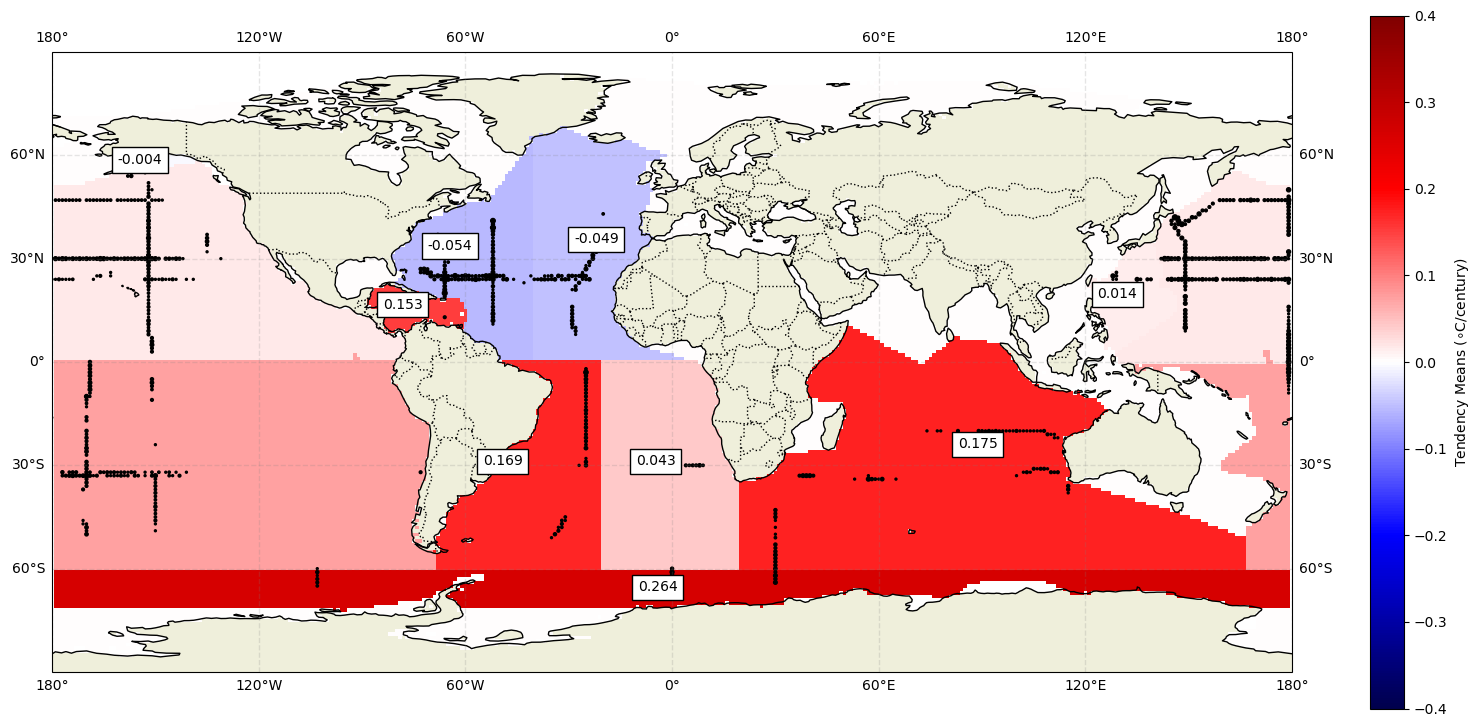

In [ ]:
fig = plt.figure(figsize = (20, 9))

ax = plt.axes(projection = ccrs.PlateCarree(central_longitude=0))
ax.set_extent((-180, 180, -90, 90))
ax.coastlines()
ax.add_feature(cfeature.LAND)
ax.add_feature(cfeature.BORDERS, linestyle = ":")
ax.gridlines(draw_labels=True, linewidth=1, color='gray', alpha=0.2, linestyle='--')
basin_means = ds.means.plot(ax = ax, cmap = "seismic", transform = ccrs.PlateCarree(), add_colorbar = False, vmin = -0.4, vmax = 0.4)
lon, lat = np.meshgrid(ds.longitude.values, ds.latitude.values)

ax.scatter(lon, lat, c = "k", s = ds.tendency.values / ds.tendency.values * ds.n.values, cmap = "seismic", vmin = -0.4, vmax = 0.4, transform = ccrs.PlateCarree())

fig.colorbar(mappable = basin_means, label = r"Tendency Means ($\circ$C/century)")

#plt.savefig("./figs/colorbar.png")

for basin in basin_idxs:
    lat, lon = coords_basins[basin]
    ilat = locate(latitude, lat)
    ilon = locate(longitude, lon)
    mean = means_basins[basin][ilat, ilon]
    twosigma = std_basins[basin][ilat, ilon]
    if np.isnan(mean) == True:
        continue
    ax.text(lon - 10, lat, s = f"{mean:.3f}", bbox = dict(facecolor = "w", edgecolor = "k"))

plt.savefig("MapasTendencias.png")


55


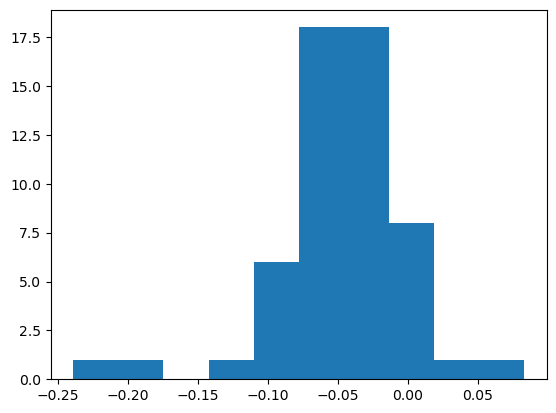

In [15]:
plt.hist(ds.tendency.where(ds.mask == 114).values.flatten());
print(len(ds.tendency.where(ds.mask == 114).values.flatten()[np.isnan(ds.tendency.where(ds.mask == 114).values.flatten()) == False]))
